**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

*   NOMBRE: Darío Martín Romero Cruz 
*   MATRÍCULA: A01841015

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [2]:
cancer_df = pd.read_csv('breast_cancer.csv', sep = ',', index_col = 'id') #Leer informacion
cancer_df.sort_index(inplace = True)

#Imprimir resultados
print(f'\nTotal de filas: {cancer_df.shape[0]:,}')
print(f'Total de columnas: {cancer_df.shape[1]:,}')
print('\nTipos de datos del archivo:\n')
cancer_df.info()

#Columnas numericas y categoricas
num_cols = cancer_df.select_dtypes(include = np.number).columns
cat_cols = cancer_df.select_dtypes(exclude = np.number).columns
print(f'\nColumnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')

#Revisar valores faltantes
print('\nValores faltantes:')
print(cancer_df.isna().sum().to_string())

#Revisar duplicados
n = cancer_df.duplicated().sum()
print(f'\nRegistros duplicados: {n:,}')
if n > 0:
    cancer_df = cancer_df.drop_duplicates(keep = 'first').reset_index(drop = True)

#Obtener estadísticas de las columnas numericas-------------
Stat1 = cancer_df[num_cols].describe(percentiles = [0.05, 0.95])
Stat1 = pd.concat([Stat1, cancer_df[num_cols].agg(['skew', 'kurt'])]) #Agregar sesgo y curtosis
print('\n\nEstadistica descriptiva de las variables numericas')
display(Stat1.round(2))

#Obtener estadísticas de las columnas categoricas-------------
Stat2 = cancer_df[cat_cols].describe()
print('\n\nEstadistica descriptiva de las variables categóricas')
display(Stat2.round(2))


Total de filas: 569
Total de columnas: 31

Tipos de datos del archivo:

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 8670 to 911320502
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  per

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
5%,9.53,13.09,60.50,275.78,0.08,0.04,0.00,0.01,0.14,0.05,...,10.53,16.57,67.86,331.06,0.10,0.07,0.02,0.02,0.21,0.06
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
95%,20.58,27.15,135.82,1309.80,0.12,0.21,0.24,0.13,0.23,0.08,...,25.64,36.30,171.64,2009.60,0.17,0.56,0.68,0.24,0.41,0.12
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21
skew,0.94,0.65,0.99,1.65,0.46,1.19,1.40,1.17,0.73,1.30,...,1.10,0.50,1.13,1.86,0.42,1.47,1.15,0.49,1.43,1.66
kurt,0.85,0.76,0.97,3.65,0.86,1.65,2.00,1.07,1.29,3.01,...,0.94,0.22,1.07,4.40,0.52,3.04,1.62,-0.54,4.44,5.24




Estadistica descriptiva de las variables categóricas


,diagnosis
count,569
unique,2
top,B
freq,357


**Comentario:**  
* El conjunto tiene **569 registros y 31 columnas**.
* Con **30 columnas numéricas y 1 de texto (categórica)**.
* **No se encontraron registros duplicados**.
* Se presenta estadística descriptiva de cada columna.

2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

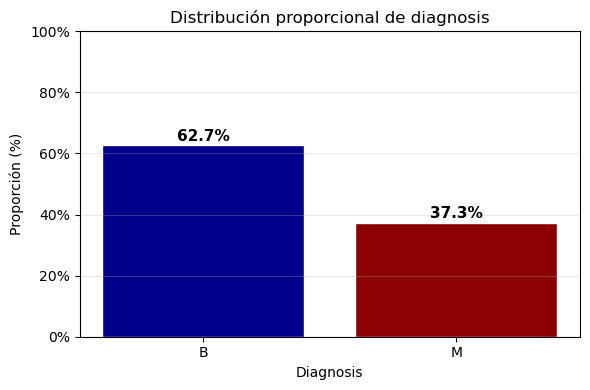

In [3]:
# Calcular proporciones
cancer_diag_count = cancer_df['diagnosis'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cancer_diag_count.index.astype(str), cancer_diag_count.values, edgecolor='white', color = ['darkblue', 'darkred'])

# Etiqueta encima de cada barra
for bar, pct in zip(bars, cancer_diag_count.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylim(0, 100)
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Proporción (%)')
ax.set_title('Distribución proporcional de diagnosis')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Comentario**: La distribución de `diagnosis` es relevante porque indica si las clases están balanceadas. Un desbalance fuerte puede sesgar al modelo hacia la clase mayoritaria y hacer que la accuracy sea engañosa (un modelo que siempre predice la clase dominante tendría alta exactitud sin valor real). Esto justifica el uso de métricas como recall y precisión. En este caso hay ~63% benignos y ~37% malignos, un desbalance moderado a tener en cuenta.

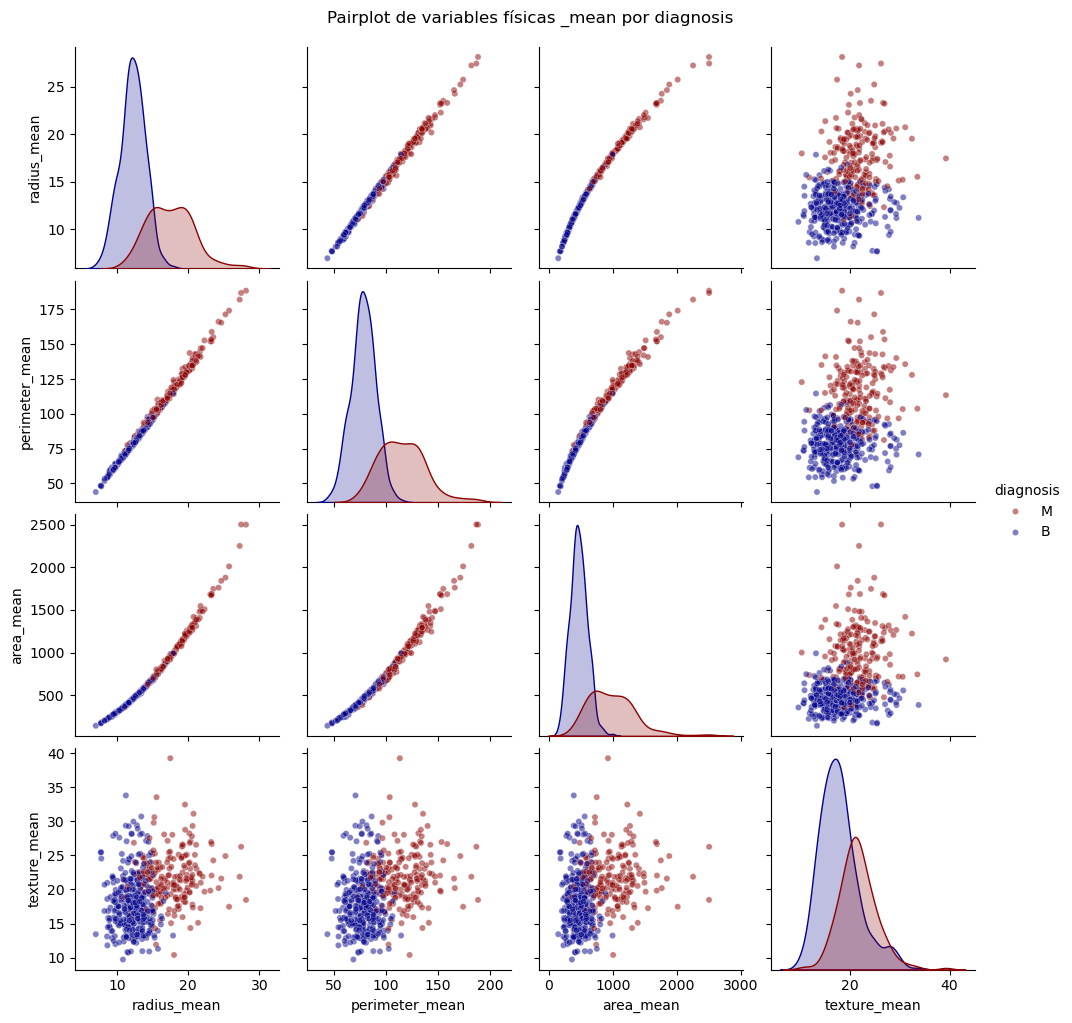

In [4]:
cols = ['radius_mean', 'perimeter_mean', 'area_mean', 'texture_mean', 'diagnosis']

sns.pairplot(
    cancer_df[cols],
    hue='diagnosis',
    palette={'B': 'darkblue', 'M': 'darkred'},
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='kde'
)

plt.suptitle('Pairplot de variables físicas _mean por diagnosis', y=1.02)
plt.show()

**Comentarios**: 
* Se observa cierta relación lineal entre el radio y el perímetro del tumor.
* Una relación casi lineal entre el area del tumor y su radio y perimetro (linea ligeramente convexa).
* Por la separación de las nubes de puntos por colores, se observa que valores más altos de radio, perimetro y área tienden a ser tumores **malignos**. Sin embargo esto no es tan marcado en la textura.

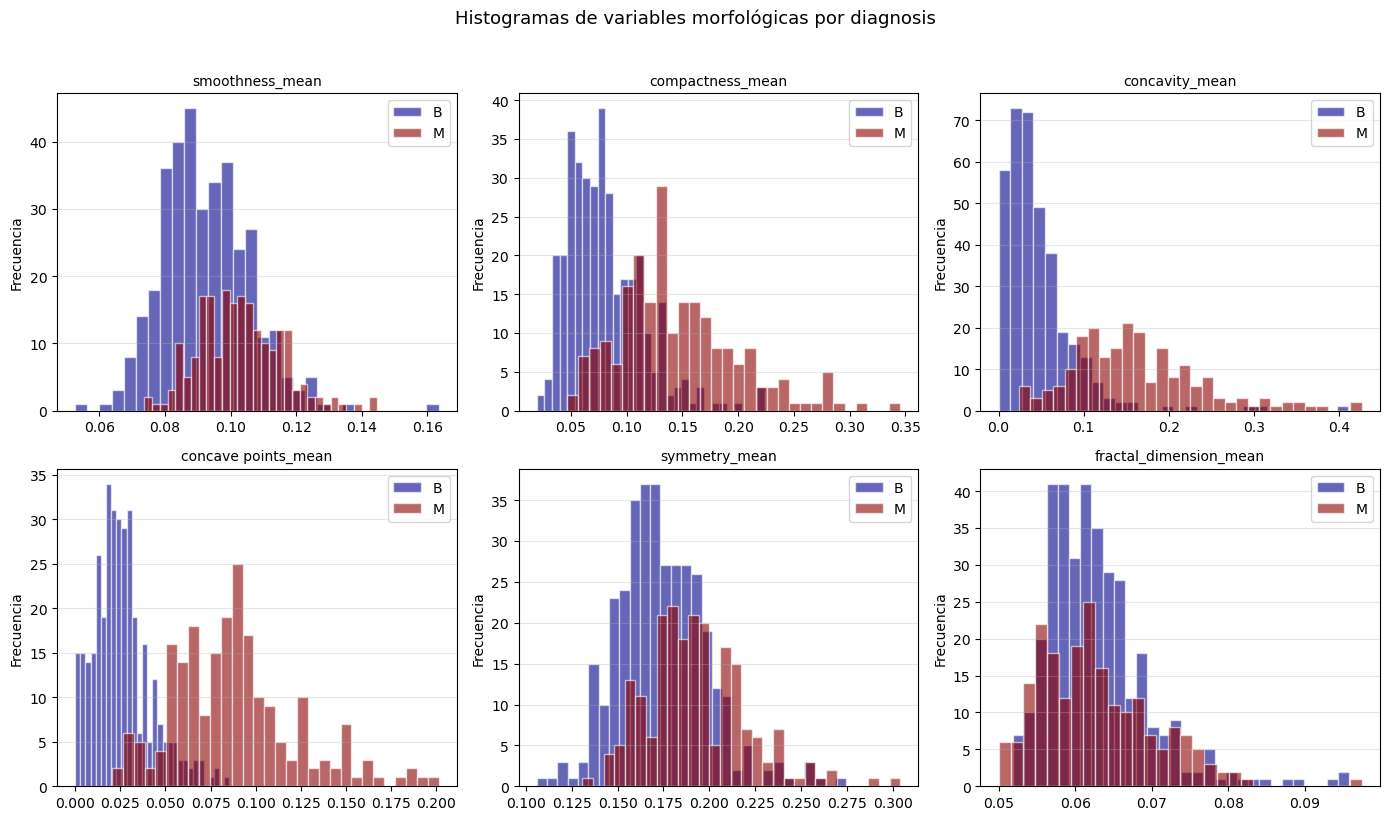

In [5]:
morph_cols = [
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, morph_cols):
    for label, color in [('B', 'darkblue'), ('M', 'darkred')]:
        ax.hist(
            cancer_df[cancer_df['diagnosis'] == label][col],
            bins=30,
            alpha=0.6,
            color=color,
            label=label,
            edgecolor='white'
        )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Histogramas de variables morfológicas por diagnosis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Comentarios:**
* Las variables que mejor podrían servir como identificador del tipo de tumor podrían ser concavidad de los contornos (`concavity_mean`) y su número de puntos cóncavos (`concave points_means`) aunque probablemente estas dos variables estén correlacionadas entre sí. 
* Un tercer candidato aunque quizá menos fuerte podría ser la compacidad (`compactness_mean`). Sin embargo esto era de esperarse ya que parece estar formulado de perímetro y área, que anteriormente si se vio que se diferenciaban por `diagnosis`.

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [6]:
cancer_copy = cancer_df.copy()

#Tomar solo columnas numericas y aplicar correlación de Pearson
def corr_cancer_copy(df, display_df = True):
    df = df.reindex(sorted(df.columns), axis=1)
    corr = df.drop(columns = 'diagnosis').corr(method = 'pearson')

    high_corr = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
                .reset_index().rename(columns={'level_0': 'Val1', 'level_1': 'Val2', 0: 'Corr'})
                .query('Corr > 0.9')).sort_values(['Corr'], ascending = False).reset_index(drop = True)
    if display_df:
        print('Parejas de variables con alta correlacion:')
        display(high_corr.round(4))
    return(corr)

corr = corr_cancer_copy(cancer_copy)

#Eliminar las columnas worst
cols_to_drop = [col for col in cancer_copy.columns if col[-6:] == '_worst']
cancer_copy.drop(columns = cols_to_drop, inplace = True)
print(f'Cantidad de columnas eliminadas con terminación "_worst": {len(cols_to_drop):,}\n\n')

#Tomar solo columnas numericas y aplicar correlación de Pearson
corr = corr_cancer_copy(cancer_copy)

#Eliminar radio y perimetro, y actualizar matriz de correlaciones
cancer_copy.drop(columns = ['radius_mean', 'radius_se', 'perimeter_mean', 'perimeter_se'], inplace = True)
corr = corr_cancer_copy(cancer_copy, False)
nCorr = len(corr.columns)
print('Cantidad de columnas eliminadas relacionadas con radio y perimetro: 4')
cols_to_drop += ['radius_mean', 'radius_se', 'perimeter_mean', 'perimeter_se']


Parejas de variables con alta correlacion:


,Val1,Val2,Corr
0,perimeter_mean,radius_mean,0.9979
1,perimeter_worst,radius_worst,0.9937
2,area_mean,radius_mean,0.9874
3,area_mean,perimeter_mean,0.9865
4,area_worst,radius_worst,0.9840
5,area_worst,perimeter_worst,0.9776
6,perimeter_se,radius_se,0.9728
7,perimeter_mean,perimeter_worst,0.9704
8,radius_mean,radius_worst,0.9695
9,perimeter_mean,radius_worst,0.9695


Cantidad de columnas eliminadas con terminación "_worst": 10


Parejas de variables con alta correlacion:


,Val1,Val2,Corr
0,perimeter_mean,radius_mean,0.9979
1,area_mean,radius_mean,0.9874
2,area_mean,perimeter_mean,0.9865
3,perimeter_se,radius_se,0.9728
4,area_se,radius_se,0.9518
5,area_se,perimeter_se,0.9377
6,concave points_mean,concavity_mean,0.9214


Cantidad de columnas eliminadas relacionadas con radio y perimetro: 4


**Comentario:** Dado que el área ya toma en cuenta de forma implicita el radio y perímetro del tumor, yo me quedaría con esta medida, descartando todas las columnas relacionadas a las otras dos.

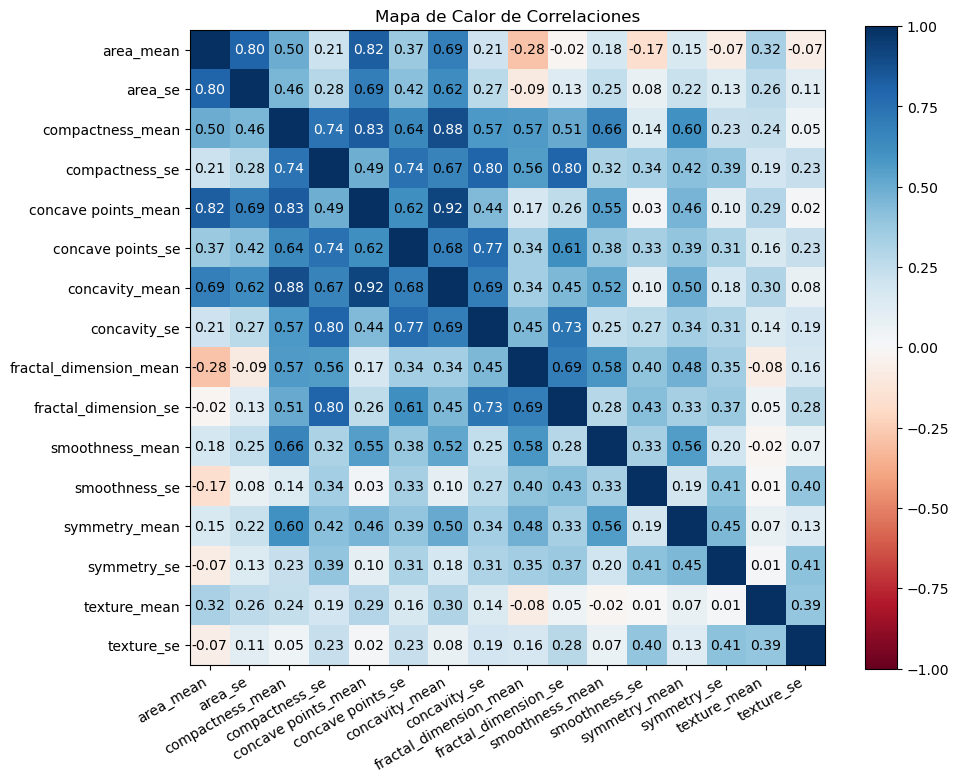

Cantidad de columnas eliminadas relacionadas con concavidad y compacidad: 4


In [7]:
#Dibujar mapa de calor
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, vmin = -1, vmax = 1, cmap = 'RdBu')

#Etiquetas
ax.set_xticks(range(nCorr))
ax.set_yticks(range(nCorr))

ax.set_xticklabels(corr.columns, rotation = 30, ha = 'right')
ax.set_yticklabels(corr.columns)

#Agregar valores
for i in range(nCorr):
    for j in range(nCorr):
        if i != j:
            TxtColor = 'white' if abs(corr.iloc[i,j]) > 0.7 else 'black'
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 10, color = TxtColor)

# Barra de colores
fig.colorbar(im)
ax.set_title('Mapa de Calor de Correlaciones')

fig.tight_layout()
plt.show()

#Eliminación de variables
cancer_copy.drop(columns = ['concavity_mean', 'concavity_se', 'compactness_mean', 'compactness_se'], inplace = True)
print('Cantidad de columnas eliminadas relacionadas con concavidad y compacidad: 4')
cols_to_drop += ['concavity_mean', 'concavity_se', 'compactness_mean', 'compactness_se']

**Comentario:** 
* El único par con correlación superior a 0.9 es `concavity_mean` y `concave points_mean` (0.92). Se elimina `concavity_mean` ya que el número de puntos cóncavos es una medida más directa e interpretable de la irregularidad del contorno.
* Adicionalmente se elimina `compactness_mean`. Aunque su correlación máxima (0.88 con `concavity_mean`) no supera el umbral de 0.9, es una variable formulada a partir de otras medidas(perímetro y área) ya tratadas en el análisis, por lo que aporta redundancia.
* El resto de las variables se conservan.

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [8]:
#Asignación de las variables X y Y
X = cancer_df.drop(columns='diagnosis')
y = cancer_df['diagnosis']

#Codificación de la variable de salida
y = (y == 'M').astype(int)

#División de los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#Funcion para imprimir las métricas de evaluación
def evaluate_model(y_true, y_pred, model_name):

    # Dataframe con los resultados
    results = pd.DataFrame([{
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred)
    }])
    
    # Imprimir resultados
    print(f'{model_name}')
    for val in results.columns:
        print(f'  {(val + ":").ljust(10)} {results.iloc[0][val]:.4f}')
    
    # Regresar matriz de resultados
    results.insert(0, 'model', model_name)
    return results

5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [9]:
#Creación del transformador. cols_to_drop se definio en el punto 3.
preprocessing = ColumnTransformer(
    transformers = [('drop', 'drop', cols_to_drop)],
    remainder = 'passthrough'
)

#Creación de pipeline
pipeline_corr = make_pipeline(
    preprocessing,
    LogisticRegression(max_iter = 5000, random_state = 1)
)

#Fit y evaluación
pipeline_corr.fit(X_train, y_train)
y_pred_corr = pipeline_corr.predict(X_test)
results = evaluate_model(y_test, y_pred_corr, 'Correlation_Clean')

Correlation_Clean
  recall:    0.8085
  precision: 0.9048
  accuracy:  0.8860


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [10]:
# Creación de pipeline
pipeline_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components = 0.90),
    LogisticRegression(max_iter = 5000, random_state = 1)
)

# fit aplica secuencialmente: escala -> reduce dimensionalidad -> entrena -> evalua
pipeline_pca.fit(X_train, y_train)
y_pred_pca = pipeline_pca.predict(X_test)
results_pca = evaluate_model(y_test, y_pred_pca, 'Standard_PCA')

# n_components_ es el atributo que guarda cuántos componentes seleccionó PCA automáticamente
n_components = pipeline_pca.named_steps['pca'].n_components_
print(f'\nComponentes principales usados: {n_components}')

# Concatenar resultados
results = pd.concat([results, results_pca], ignore_index = True)

Standard_PCA
  recall:    0.8723
  precision: 0.9535
  accuracy:  0.9298

Componentes principales usados: 7


7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [11]:
# Creación de pipeline, Yeo-Johnson ya normaliza las variables
pipeline_yeo = make_pipeline(
    preprocessing,
    PowerTransformer(method = 'yeo-johnson'),
    LogisticRegression(max_iter = 5000, random_state = 1)
)

# fit
pipeline_yeo.fit(X_train, y_train)
y_pred_yeo = pipeline_yeo.predict(X_test)
results_yeo = evaluate_model(y_test, y_pred_yeo, 'Correlation_Yeo')

# Concatenar resultados
results = pd.concat([results, results_yeo], ignore_index = True)

Correlation_Yeo
  recall:    0.8936
  precision: 0.9767
  accuracy:  0.9474


8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.

Número de predictores: 12


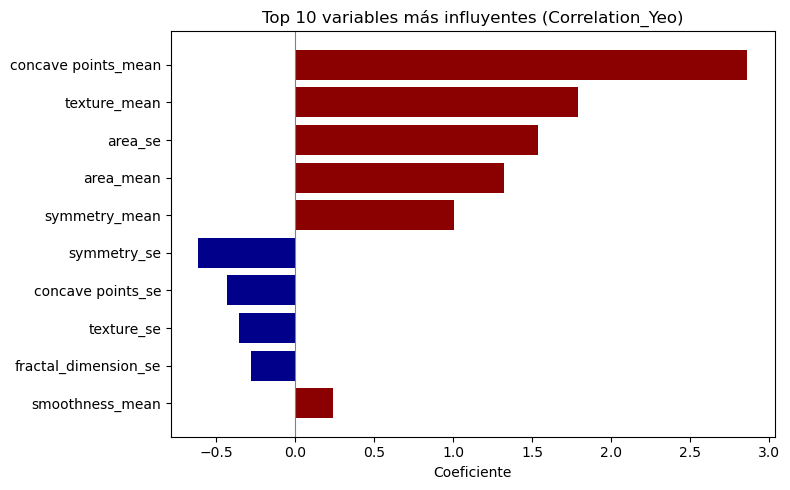

In [12]:
#feature_names = pipeline_yeo[:-1].get_feature_names_out()
feature_names = [name.replace('remainder__', '') for name in pipeline_yeo[:-1].get_feature_names_out()]
print(f'Número de predictores: {len(feature_names)}')

coefs = pipeline_yeo.named_steps['logisticregression'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
top10 = coef_df.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['darkred' if c > 0 else 'darkblue' for c in top10['coef']]
ax.barh(top10['feature'], top10['coef'], color=colors)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Coeficiente')
ax.set_title('Top 10 variables más influyentes (Correlation_Yeo)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Comentario:** Se emplearon 12 predictores tras la eliminación de columnas correlacionadas.

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

,model,recall,precision,accuracy
0,Correlation_Clean,0.8085,0.9048,0.8860
1,Standard_PCA,0.8723,0.9535,0.9298
2,Correlation_Yeo,0.8936,0.9767,0.9474


Se observa que el mejor modelo es Correlation_Yeo


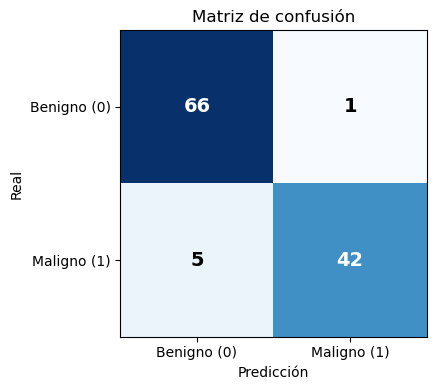

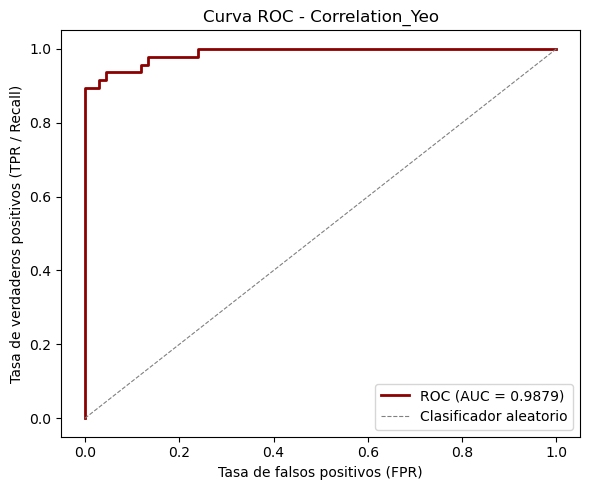

In [13]:
display(results.round(4))
print('Se observa que el mejor modelo es Correlation_Yeo')

# matriz de confusión considerando el modelo Yeo
cm = confusion_matrix(y_test, y_pred_yeo)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

# Etiquetas
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Benigno (0)', 'Maligno (1)'])
ax.set_yticklabels(['Benigno (0)', 'Maligno (1)'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión')

# Valores dentro de cada celda
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#Curva Roc
y_proba = pipeline_yeo.predict_proba(X_test)[:, 1]   # probabilidades de la clase positiva
fpr, tpr, thresholds = roc_curve(y_test, y_proba)     # tasas de falsos y verdaderos positivos
auc = roc_auc_score(y_test, y_proba)                  # área bajo la curva

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkred', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=0.8, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR / Recall)')
ax.set_title('Curva ROC - Correlation_Yeo')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Comentarios:**

* **Matriz de confusión:** cada celda indica:
  * *Verdaderos negativos (arriba-izq):* tumores benignos correctamente clasificados como benignos.
  * *Falsos positivos (arriba-der):* tumores benignos clasificados erróneamente como malignos (falsa alarma).
  * *Falsos negativos (abajo-izq):* tumores malignos clasificados erróneamente como benignos. Es el error más costoso en un contexto médico, ya que implica no detectar un cáncer.
  * *Verdaderos positivos (abajo-der):* tumores malignos correctamente detectados.

* **Curva ROC:** representa el equilibrio entre la tasa de verdaderos positivos (recall) y la tasa de falsos positivos a medida que varía el umbral de decisión. Cuanto más se acerca la curva a la esquina superior izquierda, mejor es la capacidad del modelo para distinguir entre clases. El AUC cercano a 1 confirma que el modelo separa de forma casi perfecta los tumores benignos de los malignos, muy por encima del clasificador aleatorio (línea diagonal, AUC = 0.5).

10. Grafica la distribución de las probabilidades predichas de la clase positiva (Maligno, 1) usando histogramas superpuestos, diferenciando con colores las clases reales Benigno (B) y Maligno (M).
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

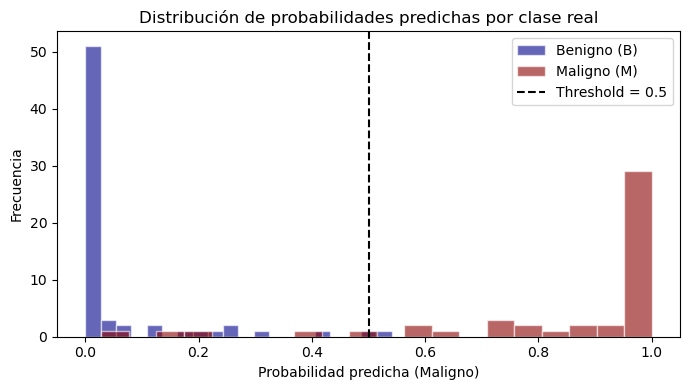

In [14]:
y_proba = pipeline_yeo.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4))
for label, color, name in [(0, 'darkblue', 'Benigno (B)'), (1, 'darkred', 'Maligno (M)')]:
    ax.hist(y_proba[y_test == label], bins=20, alpha=0.6, 
            color=color, label=name, edgecolor='white')

# Umbral por defecto de scikit-learn
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')

ax.set_xlabel('Probabilidad predicha (Maligno)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de probabilidades predichas por clase real')
ax.legend()
plt.tight_layout()
plt.show()

**Comentarios:** 
* El *Umbral* por defecto que maneja scikit learn es de 0.5.
* En el contexto médico, la métrica más importante es recall, ya que esta minimiza los falsos negativos.
* Para reducir esto, podríamos disminuir un poco el *umbral*. Podríamos caer en más falsos positivos, pero es preferible a tener falsos negativos.
* Disminuir el umbral hace que más casos se clasifiquen como malignos (positivos), subiendo recall a costa de precisión.

---

**Declaración de uso de IA**

*Anthropic. (2026). Claude Sonnet 4.6 [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://claude.ai/

---